# Project Foundations for Data Science: FoodHub Data Analysis

**Marks: 40**

**Exploratory Data Analysis (EDA)**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [2]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

import textwrap

# for ignoring warnings
import warnings
warnings.filterwarnings('ignore')

# Command to tell Python to actually display the graphs
%matplotlib inline

### Understanding the structure of the data

In [3]:
# uncomment and run the following lines for Google Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
path_foodhub="/content/drive/MyDrive/COLAB_PROJECT_week1/foodhub_order (1).csv"
df = pd.read_csv(path_foodhub)
#/content/drive/MyDrive/COLAB_PROJECT_week1

### **Question 1:** How many rows and columns are present in the data?

In [ ]:
# Write your code here
df.shape


(1898, 9)

#### Observations:
The data contains 1898 rows and 9 columns


### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used)

In [ ]:
# Use info() to print a concise summary of the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


In [ ]:
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


In [ ]:
df.tail()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
1893,1476701,292602,Chipotle Mexican Grill $1.99 Delivery,Mexican,22.31,Weekend,5,31,17
1894,1477421,397537,The Smile,American,12.18,Weekend,5,31,19
1895,1477819,35309,Blue Ribbon Sushi,Japanese,25.22,Weekday,Not given,31,24
1896,1477513,64151,Jack's Wife Freda,Mediterranean,12.18,Weekday,5,23,31
1897,1478056,120353,Blue Ribbon Sushi,Japanese,19.45,Weekend,Not given,28,24


#### Observations:
We can see that:
- The DataFrame has 9 columns as mentioned in the Data Dictionary. Data in each row corresponds to the order placed by a customer.

Concerning the data types:
- order_id is an integer
- customer_id is an integer
- restaurant_name is a name
- cuisine_type is a name
- cost_of_the_order is a real (float)
- day_of_the_week	is a name (object)
- rating is considered as an object (but this is wrong)
- food_preparation_time is an integer
- delivery_time is an integer

The column 'rating' is considered as object, what is not correct,
as it should be considered as integer or float.
This problem is due to the fact that there are several 'Not given' values in the cells.

### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method

In [ ]:
# Write your code here
df.isna().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


#### Observations:
We can see that:
- the results of the ''shape'' command indicate that the number of rows is 1898, whereas the results of the ''info'' command indicate that all the columns have 1898 values. This means that there are no missing values.
- the results of the 'isna' command indicate that there are no missing values.
- none of the variables have missing values.
- however, from the results above (using df.head and df.tail), one can see that the 'rating' column includes several 'Not given' values. This will be a problem when performing the statistical analysis.   



### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed?

In [ ]:
# Write your code here
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,1898.0,NaN,NaN,NaN,1477495.5,548.049724,1476547.0,1477021.25,1477495.5,1477969.75,1478444.0
customer_id,1898.0,NaN,NaN,NaN,171168.478398,113698.139743,1311.0,77787.75,128600.0,270525.0,405334.0
restaurant_name,1898,178,Shake Shack,219,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cuisine_type,1898,14,American,584,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cost_of_the_order,1898.0,NaN,NaN,NaN,16.498851,7.483812,4.47,12.08,14.14,22.2975,35.41
day_of_the_week,1898,2,Weekend,1351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,1898,4,Not given,736,NaN,NaN,NaN,NaN,NaN,NaN,NaN
food_preparation_time,1898.0,NaN,NaN,NaN,27.37197,4.632481,20.0,23.0,27.0,31.0,35.0
delivery_time,1898.0,NaN,NaN,NaN,24.161749,4.972637,15.0,20.0,25.0,28.0,33.0


#### Observations:
- restaurant name has 178 unique categories. This means that there are 178 differrent restaurants
- cuisine type has 14 unique categories. This means that there are 14 different cuisine types.
- rating has 4 unique categories.
- day of the week has 2 unique categories. This is because it is either week or weekend.  
- The minimum, average, and maximum times it takes for food to be prepared once an order is placed are: minimum: 20.0; average: 27.4; median: 27.0; maximum: 35.0.

### **Question 5:** How many orders are not rated?

In [ ]:
#
df['rating'].value_counts()

,count
rating,
Not given,736
5,588
4,386
3,188


In [ ]:
df.loc[df['rating']=='Not given']

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
6,1477894,157711,The Meatball Shop,Italian,6.07,Weekend,Not given,28,21
10,1477895,143926,Big Wong Restaurant _¤¾Ñ¼,Chinese,5.92,Weekday,Not given,34,28
14,1478198,62667,Lucky's Famous Burgers,American,12.13,Weekday,Not given,23,30
...,...,...,...,...,...,...,...,...,...
1887,1476873,237616,Shake Shack,American,5.82,Weekend,Not given,26,30
1891,1476981,138586,Shake Shack,American,5.82,Weekend,Not given,22,28
1892,1477473,97838,Han Dynasty,Chinese,29.15,Weekend,Not given,29,21
1895,1477819,35309,Blue Ribbon Sushi,Japanese,25.22,Weekday,Not given,31,24


#### Observations:
- The above results indicate that there are 736 unrated orders; that is, there are 736 order whose 'rating' is 'Not given'.

- We have a problem: the 'ratings' colum contains 'Not given' values. There are 736 rows where the rating is 'Not given'.
Therefore, we are going to construct a new DataFrame (named Newdf) that does not contain 'Not given' values, and we verify the features of this new DataFrame.


In [5]:
Copydf = df.copy() #Esto crea una copia
Newdf=Copydf.loc[Copydf['rating'] != 'Not given'] #Newdf is the new dataframe
Newdf.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24
5,1477224,147468,Tamarind TriBeCa,Indian,25.22,Weekday,3,20,24
7,1477859,89574,Barbounia,Mediterranean,5.97,Weekday,3,33,30


Now we verify the data type of 'ratings' column:

In [ ]:
Newdf.info() #now we verify the data type of 'ratings' column

<class 'pandas.core.frame.DataFrame'>
Index: 1162 entries, 2 to 1896
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   order_id               1162 non-null   int64   
 1   customer_id            1162 non-null   int64   
 2   restaurant_name        1162 non-null   object  
 3   cuisine_type           1162 non-null   object  
 4   cost_of_the_order      1162 non-null   float64 
 5   day_of_the_week        1162 non-null   object  
 6   rating                 1162 non-null   float64 
 7   food_preparation_time  1162 non-null   int64   
 8   delivery_time          1162 non-null   int64   
 9   binned_cost            1162 non-null   category
dtypes: category(1), float64(2), int64(4), object(3)
memory usage: 92.4+ KB


As 'ratings' is considered as object, we must convert it to float or integer, and then we verify the features of the created DataFrame:

In [6]:
#As 'ratings' is considered as object, we must convert it to float or integer
Newdf['rating'] = Newdf['rating'].astype(str).astype(float)
Newdf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1162 entries, 2 to 1896
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1162 non-null   int64  
 1   customer_id            1162 non-null   int64  
 2   restaurant_name        1162 non-null   object 
 3   cuisine_type           1162 non-null   object 
 4   cost_of_the_order      1162 non-null   float64
 5   day_of_the_week        1162 non-null   object 
 6   rating                 1162 non-null   float64
 7   food_preparation_time  1162 non-null   int64  
 8   delivery_time          1162 non-null   int64  
dtypes: float64(2), int64(4), object(3)
memory usage: 90.8+ KB


Now, we verify the counts of the categories of 'rating':

In [7]:
#Now, we verify the counts of the categories of 'rating'
Newdf['rating'].value_counts()

,count
rating,
5.0,588
4.0,386
3.0,188


In [8]:
Newdf.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,1162.0,NaN,NaN,NaN,1477519.642857,546.871297,1476547.0,1477062.25,1477523.5,1477991.75,1478444.0
customer_id,1162.0,NaN,NaN,NaN,171939.471601,114551.215031,5139.0,77540.0,128655.5,276066.25,403019.0
restaurant_name,1162,156,Shake Shack,133,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cuisine_type,1162,14,American,368,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cost_of_the_order,1162.0,NaN,NaN,NaN,16.760766,7.572578,4.47,12.13,14.6,22.75,35.41
day_of_the_week,1162,2,Weekend,822,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,1162.0,NaN,NaN,NaN,4.344234,0.741478,3.0,4.0,5.0,5.0,5.0
food_preparation_time,1162.0,NaN,NaN,NaN,27.381239,4.677922,20.0,23.0,27.0,32.0,35.0
delivery_time,1162.0,NaN,NaN,NaN,24.154045,4.930999,15.0,20.0,25.0,28.0,33.0


# **Univariate analysis**

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration)

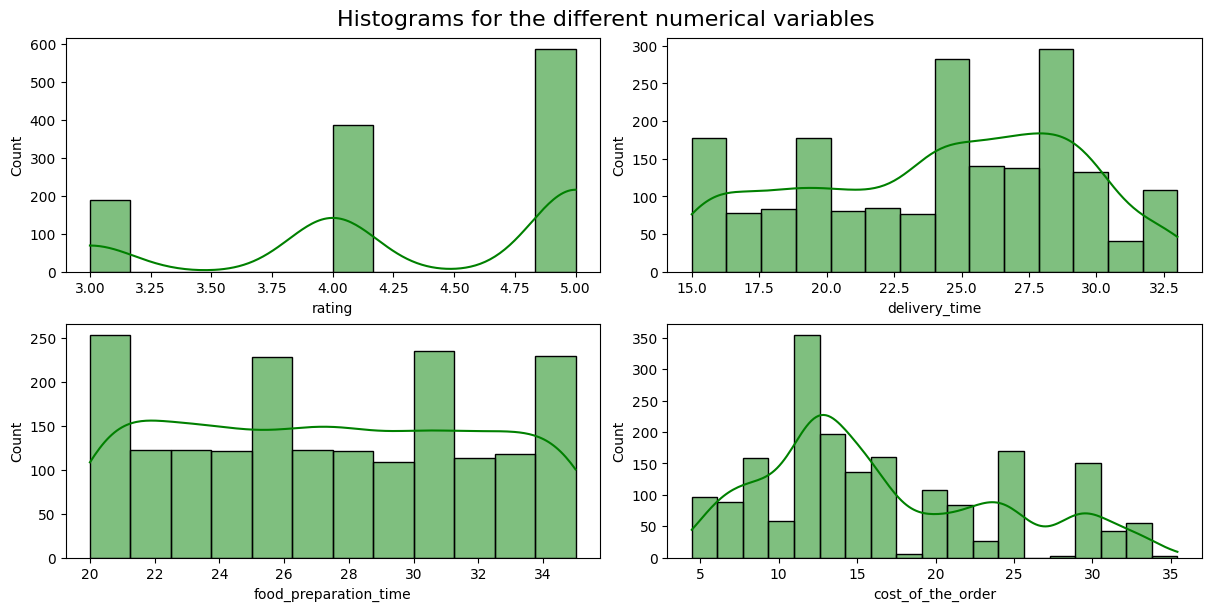

In [ ]:
fig, axes = plt.subplots(2, 2, sharex=False, constrained_layout=True, figsize=(12,6))#(16,8)
fig.suptitle('Histograms for the different numerical variables', fontsize=16)

sns.histplot(ax=axes[0, 0], data=Newdf, x='rating',color='green',kde = True);
sns.histplot(ax=axes[0, 1], data=df, x='delivery_time',color='green',kde = True);
sns.histplot(ax=axes[1, 0], data=df, x='food_preparation_time',color='green',kde = True);
sns.histplot(ax=axes[1, 1], data=df, x='cost_of_the_order',color='green',kde = True);

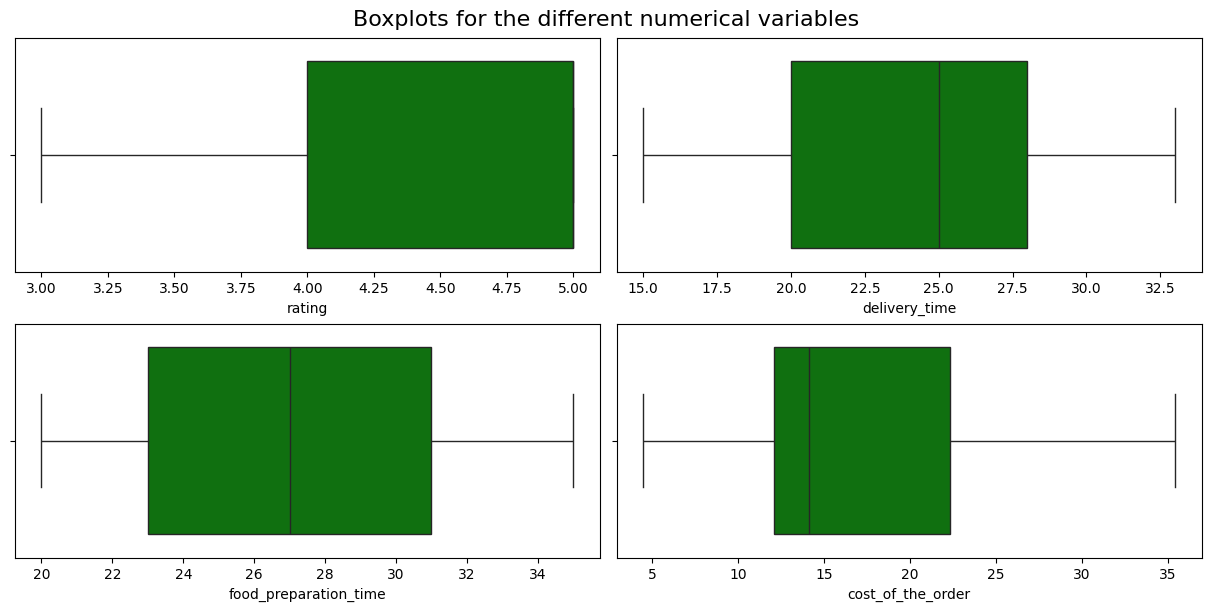

In [ ]:
fig, axes = plt.subplots(2, 2, sharex=False, constrained_layout=True, figsize=(12,6))#(16,8)
fig.suptitle('Boxplots for the different numerical variables', fontsize=16)

sns.boxplot(ax=axes[0, 0], data=Newdf, x='rating',color='green');

sns.boxplot(ax=axes[0,1], data=df, x='delivery_time',color='green');

sns.boxplot(ax=axes[1, 0], data=df, x='food_preparation_time',color='green');

sns.boxplot(ax=axes[1,1], data=df, x='cost_of_the_order',color='green');

**Figures with count as output**

Text(0.5, 1.0, 'count of orders vs rating')

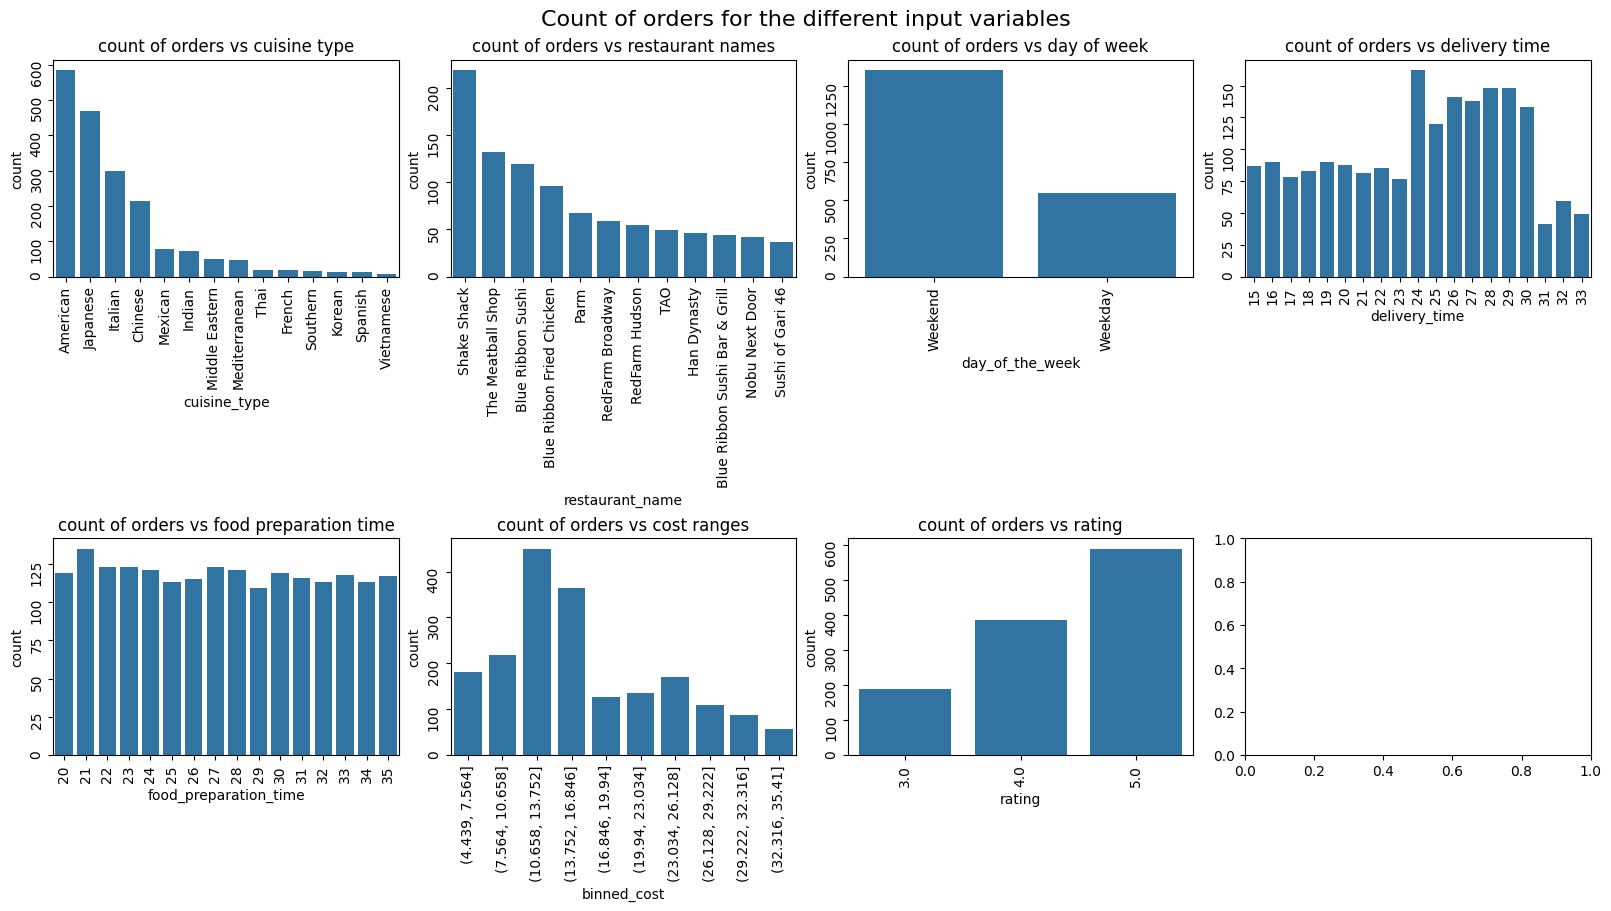

In [9]:
fig, axes = plt.subplots(2, 4, sharex=False, constrained_layout=True, figsize=(16,9))#(16,8)
fig.suptitle('Count of orders for the different input variables', fontsize=16)
Newdf['rating'] = Newdf['rating'].astype(str).astype(float)
#Newdf['rating'] = Newdf['rating'].astype(str).astype(float)

#First subfigure #plt.subplot(231)
order = df['cuisine_type'].value_counts().index
sns.countplot(data=df, x='cuisine_type',order=order, ax = axes[0,0]);#, hue='day_of_the_week',) ;
#plt.xticks(rotation=90)
axes[0,0].tick_params(rotation=90)#xticks(rotation=90)
axes[0,0].set_title('count of orders vs cuisine type')

#Second subfigure
order = df['restaurant_name'].value_counts().nlargest(12).index
#order_restaurname = df['restaurant_name'].value_counts().nlargest(12).index
sns.countplot(data=df, x='restaurant_name',order=order, ax = axes[0,1]);#, hue='day_of_the_week',) ;
#plt.xticks(rotation=90)
axes[0,1].tick_params(rotation=90)#xticks(rotation=90)
axes[0,1].set_title('count of orders vs restaurant names')

#Third subfigure
#plt.subplot(232)
sns.countplot(data=df, x='day_of_the_week', ax = axes[0,2])#,order=order);#, hue='day_of_the_week',) ;
axes[0,2].tick_params(rotation=90)#xticks(rotation=90)
axes[0,2].set_title('count of orders vs day of week')

#Fourth subfigure
sns.countplot(data=df, x='delivery_time', ax = axes[0,3])#,order=order);#, hue='day_of_the_week',) ;
axes[0,3].tick_params(rotation=90)#xticks(rotation=90)
axes[0,3].set_title('count of orders vs delivery time')

#Fifth subfigure
sns.countplot(data=df, x='food_preparation_time', ax = axes[1,0])#,order=order);#, hue='day_of_the_week',) ;
axes[1,0].tick_params(rotation=90)#xticks(rotation=90)
axes[1,0].set_title('count of orders vs food preparation time')

#Sixth subfigure
array_forbins = pd.array(df['cost_of_the_order'])
binned_data = pd.cut(array_forbins, bins = 10, retbins=True)#print(binned_data)
df['binned_cost'] = pd.cut(array_forbins, bins = 10)
#print(df.head())
sns.countplot(data = df, x='binned_cost', ax = axes[1,1]);#,order=order);#, hue='day_of_the_week',) ;
axes[1,1].tick_params(rotation=90)#xticks(rotation=90)
axes[1,1].set_title('count of orders vs cost ranges')

#Seventh subfigure
order_countrating = df['rating'].value_counts().index
#df_orderedrating = df['rating'].value_counts().index
####sns.countplot(data=df_orderedrating, x='rating', ax = axes[1,2])#,order=order);#, hue='day_of_the_week',) ;#En lugar de df estaba Newdf
#sns.countplot(data=df, x='rating', order = order_countrating, ax = axes[1,2])#,order=order)
sns.countplot(data=Newdf, x='rating', ax = axes[1,2])
axes[1,2].tick_params(rotation=90)
axes[1,2].set_title('count of orders vs rating')

# Conclusions univariate analysis and formulation of questions

We draw the following conclusions from the above univariate analysis:
- The 'rating' is left skewed. The 'cost of the order' is right skewed. The 'delivery time' and 'food preparation time' seem to have no defined skewness. However, from the boxplot it seems that the delivery time is left skewed.  
- The 'delivery time' histogram improves and gets left skewed when it is defined for a single restaurant, for instance 'Shake Shack'
- The histogram of food prepapration time does not improve when a single restaurant is used.  
- The histogram of 'cost of the order' improves a little when it is defined for a single restaurant, for instance 'Shake Shack'
- From the discriminated boxplots it follows that:
   - 'cost of the order' highly depends on the cuisine type
   - 'food preparation time' highly depends on the cuisine  type.  
   - 'delivery time' is highly dependent on the 'day of the week'
   - it seems that'cost of the order' and 'food preparation type' do not depend on 'day of the week'
- From the count plots it follows that:
   - the count of rating is highly dependent on the 'cuisine type'
   - the count of rating depends on the delivery time
   - the count of rating highly depends on the day of the week
   - the count of cuisine type depends on day of the week

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received?

In [10]:
# Write the code here
df['restaurant_name'].value_counts().nlargest(5)
#sorted_data = df.sort_values(by='cost', ascending=True)

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


#### Observations:
According to the above result, the top 5 restaurants in terms of the number of orders received are:  

- Shake Shack,       
- The Meatball Shop            
- Blue Ribbon Sushi            
- Blue Ribbon Fried Chicken     
- Parm

### **Question 8**: Which is the most popular cuisine on weekends?

In [11]:
Newdf_weekends=df.loc[df['day_of_the_week'] =='Weekend'];# A new DataFrame (Newdf_weekends) is created, in which only 'Weekend' values for 'day_of_the_week'
Newdf_weekends['cuisine_type'].value_counts()
#my_value_count = df['cuisine_type'].value_counts()
#my_value_count.loc[df['day_of_the_week'] == 'Weekend']

,count
cuisine_type,
American,415
Japanese,335
Italian,207
Chinese,163
Mexican,53
Indian,49
Middle Eastern,32
Mediterranean,32
Thai,15


#### Observations:
From the above result it follows that the most popular cuisine type on weekends is American.  


### **Question 9**: What percentage of the orders cost more than 20 dollars?

In [12]:
Newdf_higher20 = df.loc[df['cost_of_the_order'] > 20] # A new DataFrame is created, 'Newdf_higher20', which satisfies cost_of_the_order > 20
Percentage_higher20 = round(100*len(Newdf_higher20)/len(df),2)

print('The percentage of orders that cost more than 20 dollars is: \n',Percentage_higher20, 'percent')

The percentage of orders that cost more than 20 dollars is: 
 29.24 percent


- According to the above result, the number of orders with cost higher than 20 dollars is: 555.
- Total  number of orders of the original DataFrame: 1898.
- Using these two values, we have: Percentage: = 100*555/1898 =29.24%
- As final conclusion, the percentage of the orders that cost more than 20 dollars is 29.24 %

### **Question 10**: What is the mean order delivery time?

In [13]:
# Write the code here
Mean_delivertime = round(df['delivery_time'].mean(),2)

print('The mean order delivery time is: \n',Mean_delivertime)

The mean order delivery time is: 
 24.16


### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed

In [14]:
# Write the code here
top3customers = df['customer_id'].value_counts().nlargest(3)

print('The IDs of the top 3 most frequent customers and number of orders are: \n', top3customers )
#order_restaurname = df['restaurant_name'].value_counts().nlargest(15).index

The IDs of the top 3 most frequent customers and number of orders are: 
 customer_id
52832    13
47440    10
83287     9
Name: count, dtype: int64


# **Figures of multivariate analysis**

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables)

**Figures with rating as output**

Text(0.5, 1.0, 'rating vs cost ranges')

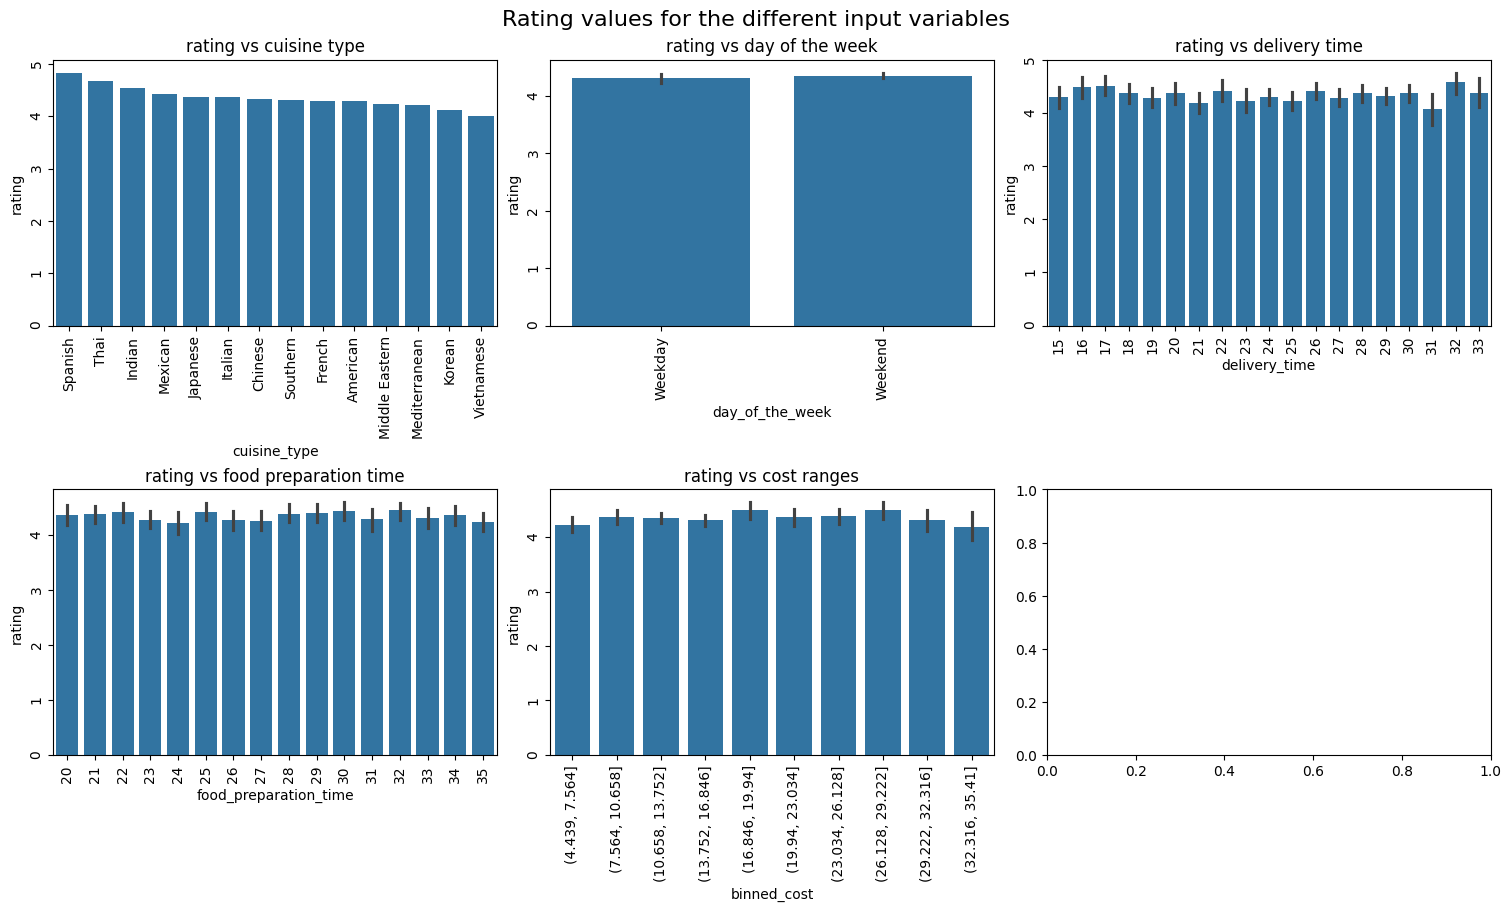

In [15]:
fig, axes = plt.subplots(2, 3, sharex=False, constrained_layout=True, figsize=(15,9))#(16,8)
fig.suptitle('Rating values for the different input variables', fontsize=16)
NewdfSpanish = Newdf #Newdf.loc[Newdf['cuisine_type'] == 'Italian']

#Development of binned cost
array_forbins = pd.array(Newdf['cost_of_the_order'])
binned_data = pd.cut(array_forbins, bins = 10, retbins=True)#print(binned_data)
Newdf['binned_cost'] = pd.cut(array_forbins, bins = 10)



#First subfigure
#Groupf the dataframe by 'cuisine_type', get the mean rating of each group, and then sort by the mean rating in descending order
GroupedRatingvscuisinetype = (
                            Newdf.groupby('cuisine_type')['rating'].mean().sort_values(ascending=False)
                            .reset_index()
                            )
sns.barplot(x=GroupedRatingvscuisinetype['cuisine_type'], y = GroupedRatingvscuisinetype['rating'], data = GroupedRatingvscuisinetype, ax = axes[0,0])
axes[0,0].tick_params(rotation=90)#xticks(rotation=90)
axes[0,0].set_title('rating vs cuisine type')

#Second subfigure
sns.barplot(x='day_of_the_week', y = 'rating', data = NewdfSpanish, ax = axes[0,1])
axes[0,1].tick_params(rotation=90)#xticks(rotation=90)
axes[0,1].set_title('rating vs day of the week')

#Third subfigure
sns.barplot(x='delivery_time', y = 'rating', data = NewdfSpanish, ax = axes[0,2])
axes[0,2].tick_params(rotation=90)#xticks(rotation=90)
axes[0,2].set_title('rating vs delivery time')

#Fourth subfigure
sns.barplot(x='food_preparation_time', y = 'rating', data = NewdfSpanish, ax = axes[1,0])
axes[1,0].tick_params(rotation=90)#xticks(rotation=90)
axes[1,0].set_title('rating vs food preparation time')

#Fifth subfigure
sns.barplot(x='binned_cost', y = 'rating', data = NewdfSpanish, ax = axes[1,1])
axes[1,1].tick_params(rotation=90)#xticks(rotation=90)
axes[1,1].set_title('rating vs cost ranges')

**Figures of Delivery time as function of other input variables**

Text(0.5, 1.0, 'Cost of order vs restaurant names\nexhibiting higher number of orders')

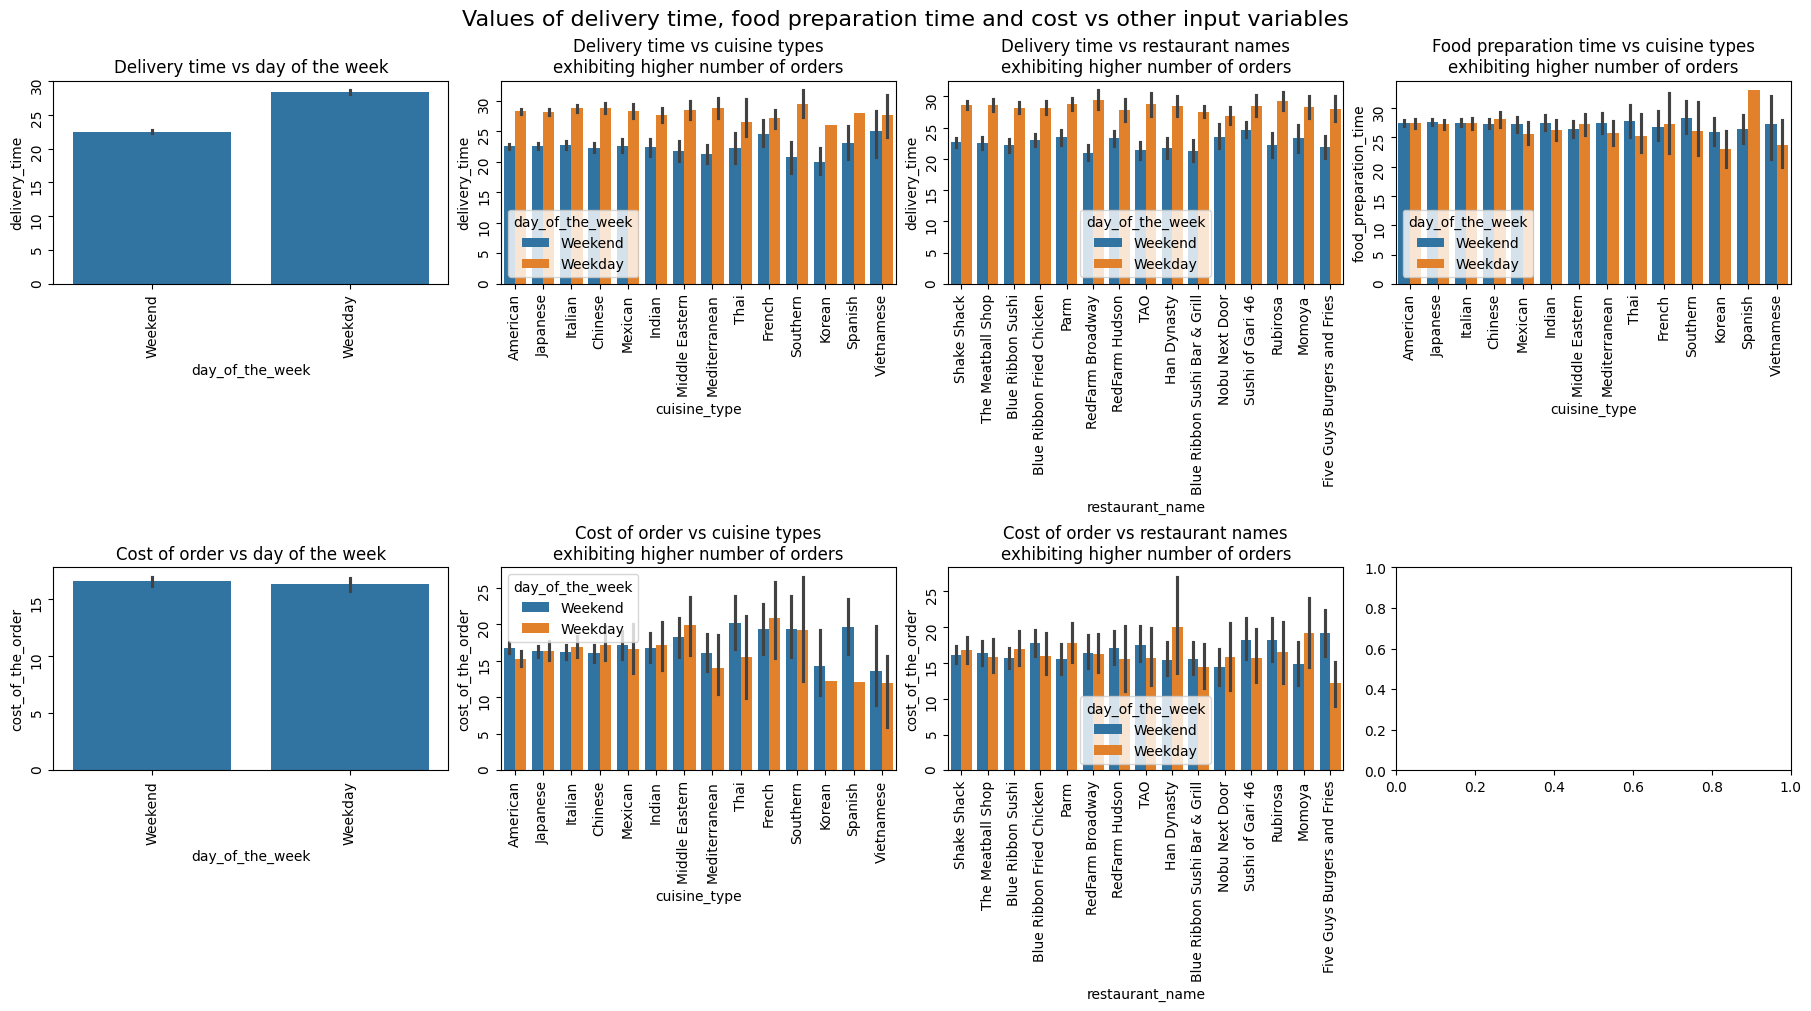

In [16]:
fig, axes = plt.subplots(2, 4, sharex=False, constrained_layout=True, figsize=(18,10))#(16,8)
fig.suptitle('Values of delivery time, food preparation time and cost vs other input variables', fontsize=16)

#First subfigure
sns.barplot(x='day_of_the_week', y = 'delivery_time', data = df, ax = axes[0,0])
axes[0,0].tick_params(rotation=90)#xticks(rotation=90)
axes[0,0].set_title('Delivery time vs day of the week')

#Second subfigure
order_cuistype = df['cuisine_type'].value_counts().index
sns.barplot(x='cuisine_type', y = 'delivery_time', data=df, order=order_cuistype, hue = 'day_of_the_week', ax = axes[0,1])
axes[0,1].tick_params(rotation=90)#xticks(rotation=90)
#axes[0,1].set_title('Delivery time vs cuisine types exhibiting higher number of orders')
wrapped_title = textwrap.fill('Delivery time vs cuisine types exhibiting higher number of orders', width=40)
axes[0,1].set_title(wrapped_title)

#Third subfigure
order_restaurname = df['restaurant_name'].value_counts().nlargest(15).index
sns.barplot(x='restaurant_name', y = 'delivery_time', data=df, order=order_restaurname, hue = 'day_of_the_week', ax = axes[0,2])
axes[0,2].tick_params(rotation=90)#xticks(rotation=90)
wrapped_title = textwrap.fill('Delivery time vs restaurant names exhibiting higher number of orders', width=40)
axes[0,2].set_title(wrapped_title)
#axes[0,2].set_title('Delivery time vs restaurant names exhibiting higher number of orders')


#Fourth subfigure
sns.barplot(x='cuisine_type', y = 'food_preparation_time', data=df, order=order_cuistype, hue = 'day_of_the_week', ax = axes[0,3])
axes[0,3].tick_params(rotation=90)#xticks(rotation=90)
#axes[0,1].set_title('Delivery time vs cuisine types exhibiting higher number of orders')
wrapped_title = textwrap.fill('Food preparation time vs cuisine types exhibiting higher number of orders', width=40)
axes[0,3].set_title(wrapped_title)

#Fourth subfigure
sns.barplot(x='day_of_the_week', y = 'cost_of_the_order', data = df, ax = axes[1,0])
axes[1,0].tick_params(rotation=90)#xticks(rotation=90)
axes[1,0].set_title('Cost of order vs day of the week')

#Fifth subfigure
sns.barplot(x='cuisine_type', y = 'cost_of_the_order', data=df, order=order_cuistype, hue = 'day_of_the_week', ax = axes[1,1])
axes[1,1].tick_params(rotation=90)#xticks(rotation=90)
wrapped_title = textwrap.fill('Cost of order vs cuisine types exhibiting higher number of orders', width=40)
axes[1,1].set_title(wrapped_title)

#Sixth subfigure
sns.barplot(x='restaurant_name', y = 'cost_of_the_order', data=df, order=order_restaurname, hue = 'day_of_the_week', ax = axes[1,2])
axes[1,2].tick_params(rotation=90)#xticks(rotation=90)
wrapped_title = textwrap.fill('Cost of order vs restaurant names exhibiting higher number of orders', width=40)
axes[1,2].set_title(wrapped_title)

**Figures with count as output, but including segmentations**

Newdf: 
    order_id  customer_id            restaurant_name   cuisine_type  \
2   1477070        66393                Cafe Habana        Mexican   
3   1477334       106968  Blue Ribbon Fried Chicken       American   
4   1478249        76942           Dirty Bird to Go       American   
5   1477224       147468           Tamarind TriBeCa         Indian   
7   1477859        89574                  Barbounia  Mediterranean   

   cost_of_the_order day_of_the_week  rating  food_preparation_time  \
2              12.23         Weekday     5.0                     23   
3              29.20         Weekend     3.0                     25   
4              11.59         Weekday     4.0                     25   
5              25.22         Weekday     3.0                     20   
7               5.97         Weekday     3.0                     33   

   delivery_time       binned_cost  
2             28  (10.658, 13.752]  
3             15  (26.128, 29.222]  
4             24  (10.658, 13.75

Text(0.5, 1.0, 'count vs delivery time segmented by day of week')

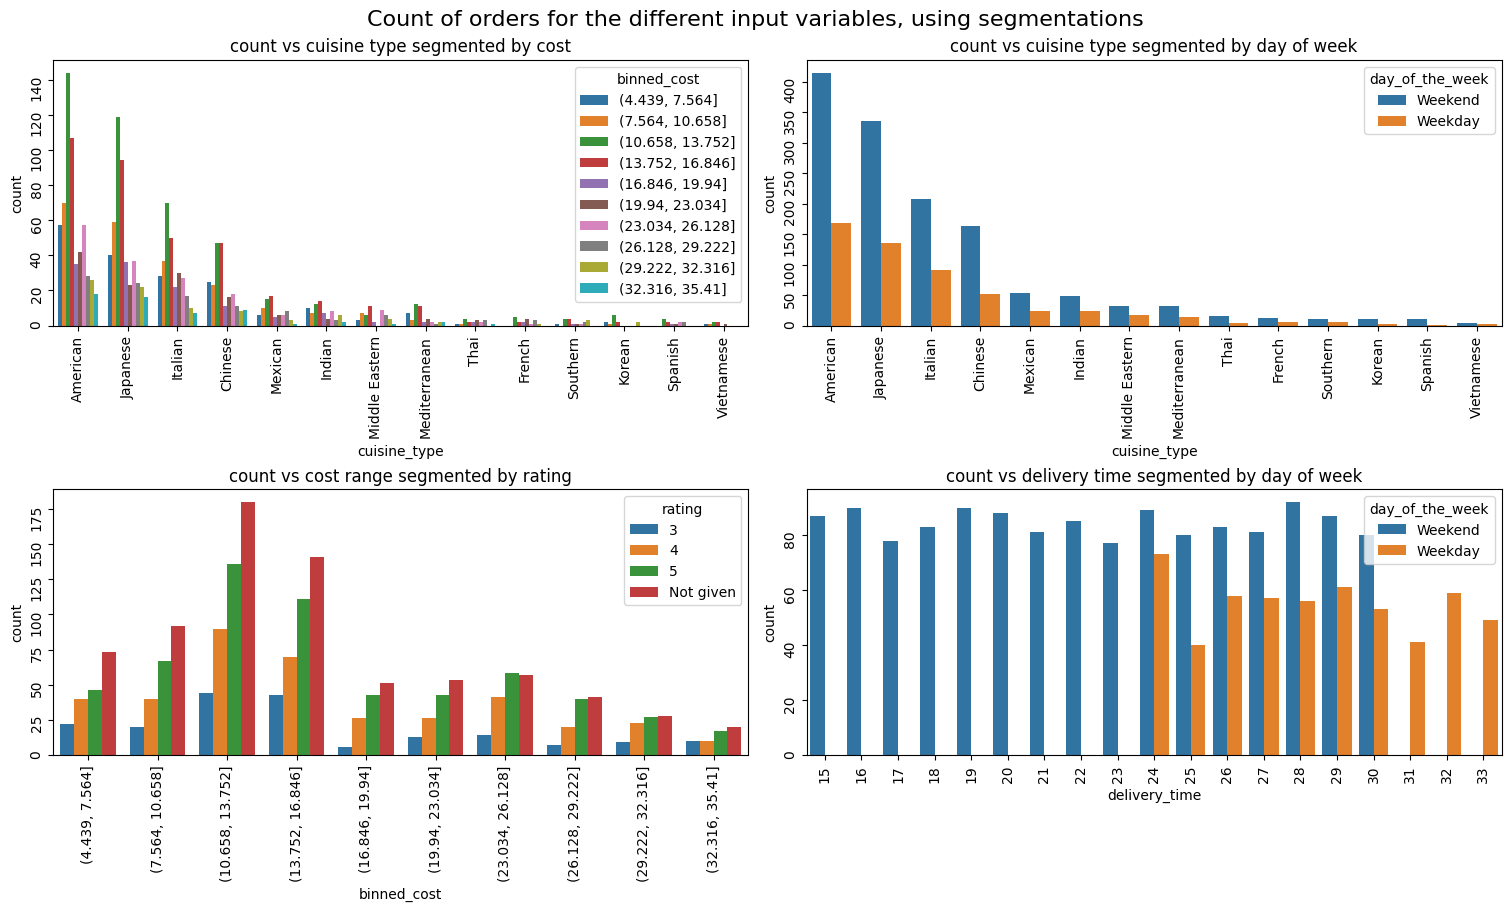

In [17]:
fig, axes = plt.subplots(2, 2, sharex=False, constrained_layout=True, figsize=(15,9))#(16,8)
fig.suptitle('Count of orders for the different input variables, using segmentations', fontsize=16)
Newdf['rating'] = Newdf['rating'].astype(str).astype(float)
print('Newdf: \n', Newdf.head())


array_forbins = pd.array(df['cost_of_the_order'])
binned_data = pd.cut(array_forbins, bins = 10, retbins=True)#print(binned_data)
df['binned_cost'] = pd.cut(array_forbins, bins = 10)

#First subfigure
order = df['cuisine_type'].value_counts().index
#print('order is ', order)
sns.countplot(data=df, x='cuisine_type',order=order, hue='binned_cost', ax = axes[0,0]) ;
axes[0,0].tick_params(rotation=90)#xticks(rotation=90)
axes[0,0].set_title('count vs cuisine type segmented by cost')

#Second subfigure
order = df['cuisine_type'].value_counts().index
sns.countplot(data=df, x='cuisine_type',order=order, hue='day_of_the_week', ax = axes[0,1]) ;
axes[0,1].tick_params(rotation=90)#xticks(rotation=90)
axes[0,1].set_title('count vs cuisine type segmented by day of week')

#Third subfigure
NewVec2 = ['3', '4', '5', 'Not given'] #The Newdf dataframe is ordered, following the rating ordered according to [3, 4, 5, Not given]
Newdf2b = df

#NewVec2 = ['3', '4', '5'] #The Newdf dataframe is ordered, following the rating ordered according to [3, 4, 5, Not given]
#Newdf2b = Newdf
Newdf2b['rating'] = pd.Categorical(Newdf2b['rating'], categories = NewVec2, ordered=True)
Newdf2b.sort_values(by = 'rating', inplace = True)
print('New newdf ordered correctly: \n', Newdf2b.head())

sns.countplot(data=Newdf2b, x='binned_cost', hue='rating', ax = axes[1,0]);
axes[1,0].tick_params(rotation=90)#xticks(rotation=90)
axes[1,0].set_title('count vs cost range segmented by rating')


#Fourth subfigure
sns.countplot(data=df, x='delivery_time', hue='day_of_the_week', ax = axes[1,1]) ; #hue='day_of_the_week',
axes[1,1].tick_params(rotation=90)#xticks(rotation=90)
axes[1,1].set_title('count vs delivery time segmented by day of week')

Newdf: 
    order_id  customer_id            restaurant_name   cuisine_type  \
2   1477070        66393                Cafe Habana        Mexican   
3   1477334       106968  Blue Ribbon Fried Chicken       American   
4   1478249        76942           Dirty Bird to Go       American   
5   1477224       147468           Tamarind TriBeCa         Indian   
7   1477859        89574                  Barbounia  Mediterranean   

   cost_of_the_order day_of_the_week  rating  food_preparation_time  \
2              12.23         Weekday     5.0                     23   
3              29.20         Weekend     3.0                     25   
4              11.59         Weekday     4.0                     25   
5              25.22         Weekday     3.0                     20   
7               5.97         Weekday     3.0                     33   

   delivery_time       binned_cost  
2             28  (10.658, 13.752]  
3             15  (26.128, 29.222]  
4             24  (10.658, 13.75

Text(0.5, 1.0, 'count vs cuisine type, for Weekends, segmented by delivery time')

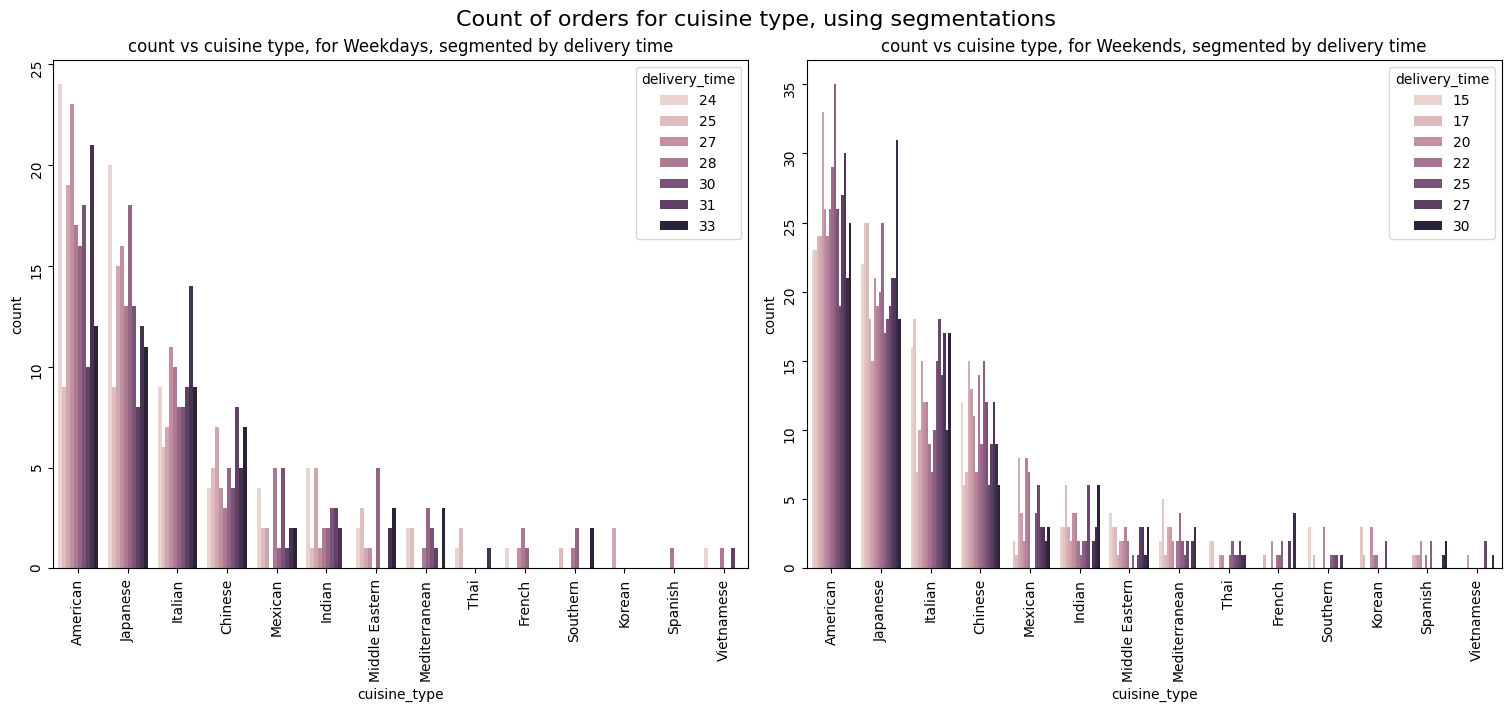

In [23]:
fig, axes = plt.subplots(1, 2, sharex=False, constrained_layout=True, figsize=(15,7))#(16,8)
fig.suptitle('Count of orders for cuisine type, using segmentations', fontsize=16)
Newdf['rating'] = Newdf['rating'].astype(str).astype(float)
print('Newdf: \n', Newdf.head())

#First subfigure
order = df['cuisine_type'].value_counts().index
#print('order is ', order)
sns.countplot(data=df[df['day_of_the_week'] =='Weekday'], x='cuisine_type',order=order, hue='delivery_time', ax = axes[0])#[0,0]) ;
axes[0].tick_params(rotation=90)#xticks(rotation=90)
axes[0].set_title('count vs cuisine type, for Weekdays, segmented by delivery time')

#Second subfigure
sns.countplot(data=df[df['day_of_the_week'] =='Weekend'], x='cuisine_type',order=order, hue='delivery_time', ax = axes[1]) ;
axes[1].tick_params(rotation=90)#xticks(rotation=90)
axes[1].set_title('count vs cuisine type, for Weekends, segmented by delivery time')

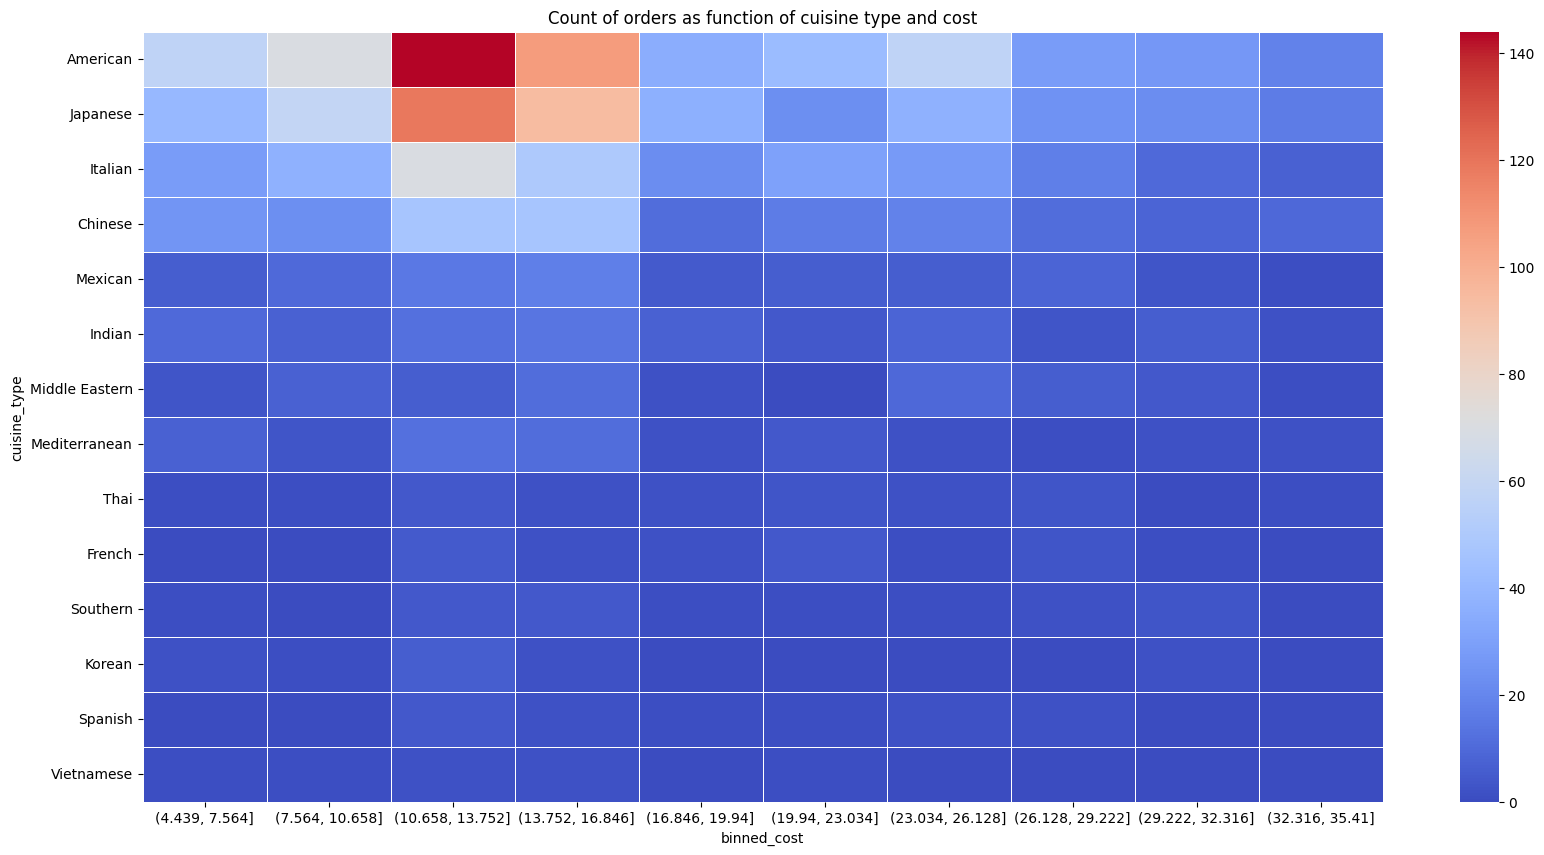

In [ ]:
#Construction of the dataframe whose columns are cuisine_type, binned_cost and count. This dataframe is necessary for the heatmap plot.
B = (
    df.groupby(['cuisine_type', 'binned_cost'])
    .size()
    .reset_index()
)
B.rename(columns={B.columns[2]: 'countvariable'}, inplace = True)
#print('B head is:'); B.head(3); print('Now, the info of B'); B.info()

#Construction of the dataframe that contains the cuisine_type ordered according to count:
Newdfgroupedsorted2 = (
                    df.groupby('cuisine_type').size().sort_values(ascending=False)
                    .reset_index()
)
#print('grouped dataframes is:',Newdfgroupedsorted2)

#Generation of the vector of only the cuisine_types (ordered according to count values) without count values. It is obtained from the above dataframe:
NewVec = Newdfgroupedsorted2['cuisine_type'].values
#print('new vector, vector de cuisint type ordenado is',NewVec)

#The B dataframe is ordered, following the cuisine types ordered according to count
B["cuisine_type"] = pd.Categorical(B["cuisine_type"], categories = NewVec, ordered=True)
B.sort_values(by = "cuisine_type", inplace = True)
#print('new b well ordered', B)

#Finally, the construction of the heatmap:
df_man = B#[Newdf.cuisine_type == 'American']
df_hm = df_man.pivot_table(index = 'cuisine_type', columns = 'binned_cost', values = 'countvariable')

plt.figure(figsize = (20, 10)) # To resize the plot
sns.heatmap(df_hm,  fmt = "d", cmap = 'coolwarm', linewidths = .5, vmin = 0)
plt.title('Count of orders as function of cuisine type and cost')
plt.show()

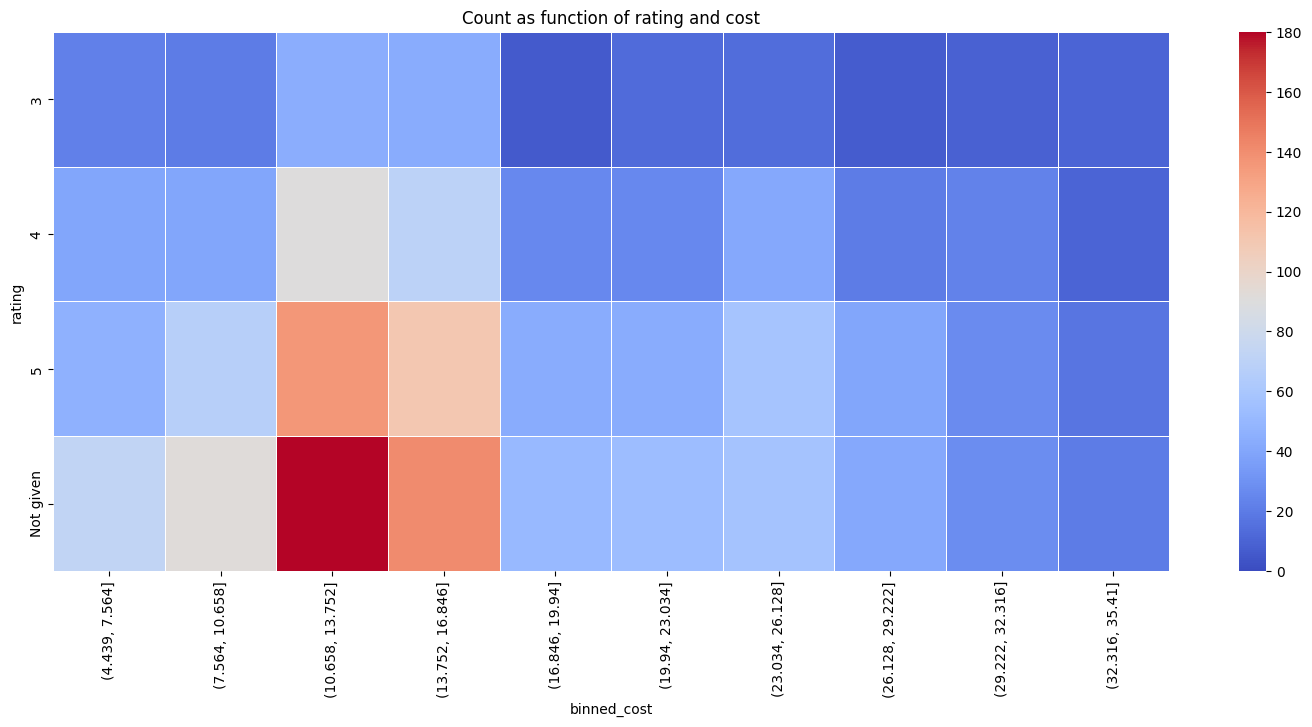

In [ ]:
#Construction of the dataframe whose columns are rating, binned_cost and count. This dataframe is necessary for the heatmep plot.
B2 = (
    df.groupby(['rating', 'binned_cost'])
    .size()
    .reset_index()
)
#print('B is:', B2); print('B shape is:', B2.shape)#B.shape; print('B head is:', B2.head(3)); print('Now, the info of B is:'); B2.info()

B2.rename(columns={B2.columns[2]: 'countvar2'}, inplace = True)
#print('Now, the info of B renamed is:'); B2.info()

#Finally, the construction of the heatmap:
df_man2 = B2#[Newdf.cuisine_type == 'American']
df_hm = df_man2.pivot_table(index = 'rating', columns = 'binned_cost', values = 'countvar2')

plt.figure(figsize = (18, 7)) # To resize the plot
sns.heatmap(df_hm,  fmt = "d", cmap = 'coolwarm', linewidths = .5, vmin = 0)
plt.title("Count as function of rating and cost")
plt.show()

**Pairplots**

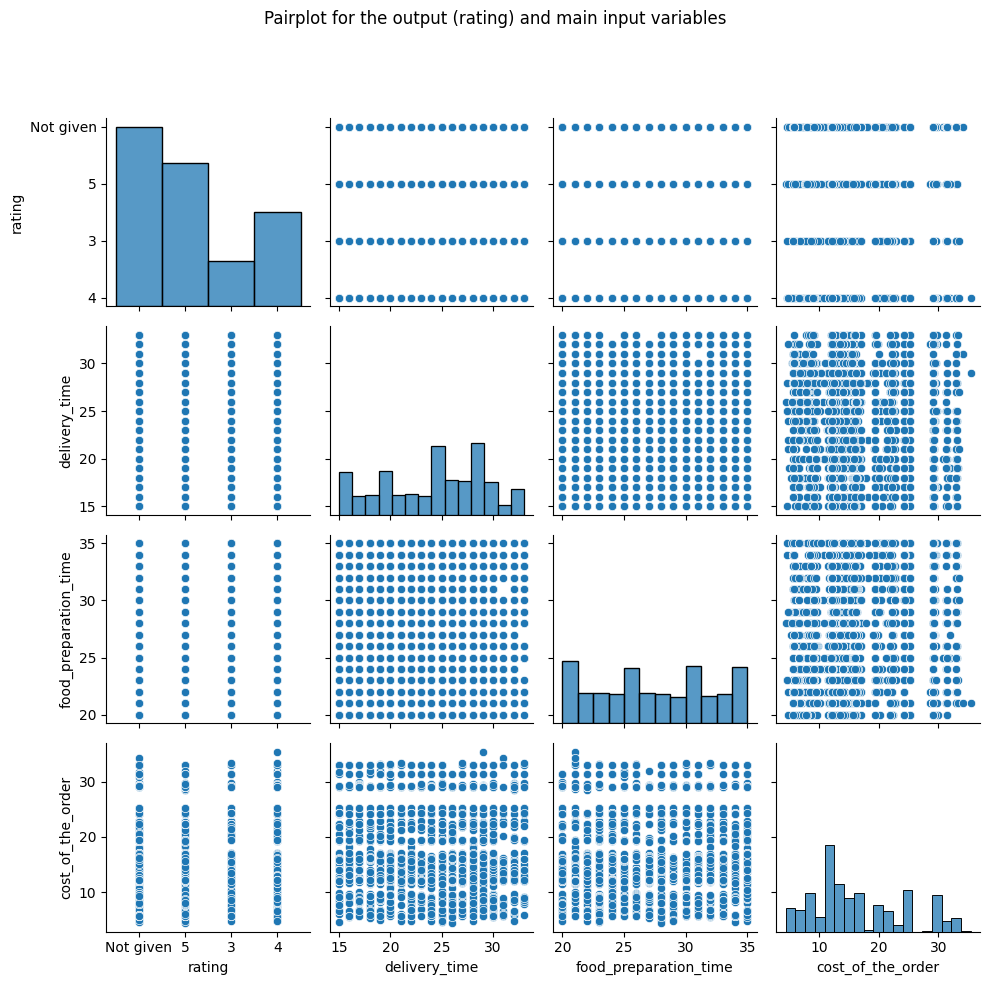

In [ ]:
###plt.figure(figsize = (20, 10)) # To resize the plot
#plt.figure(figsize = (20, 6)) # To resize the plot
####plt.figure(figsize = (20, 1)) # To resize the plot
pair_plot = sns.pairplot(data=df, vars = ['rating','delivery_time','food_preparation_time','cost_of_the_order'], palette='bright')#, height=2.2, aspect=1.5)

pair_plot.fig.suptitle('Pairplot for the output (rating) and main input variables', y=1.01)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#plt.title("Pairplot for the output (rating) and main input variables", fontsize=16)

**Heatmap:**

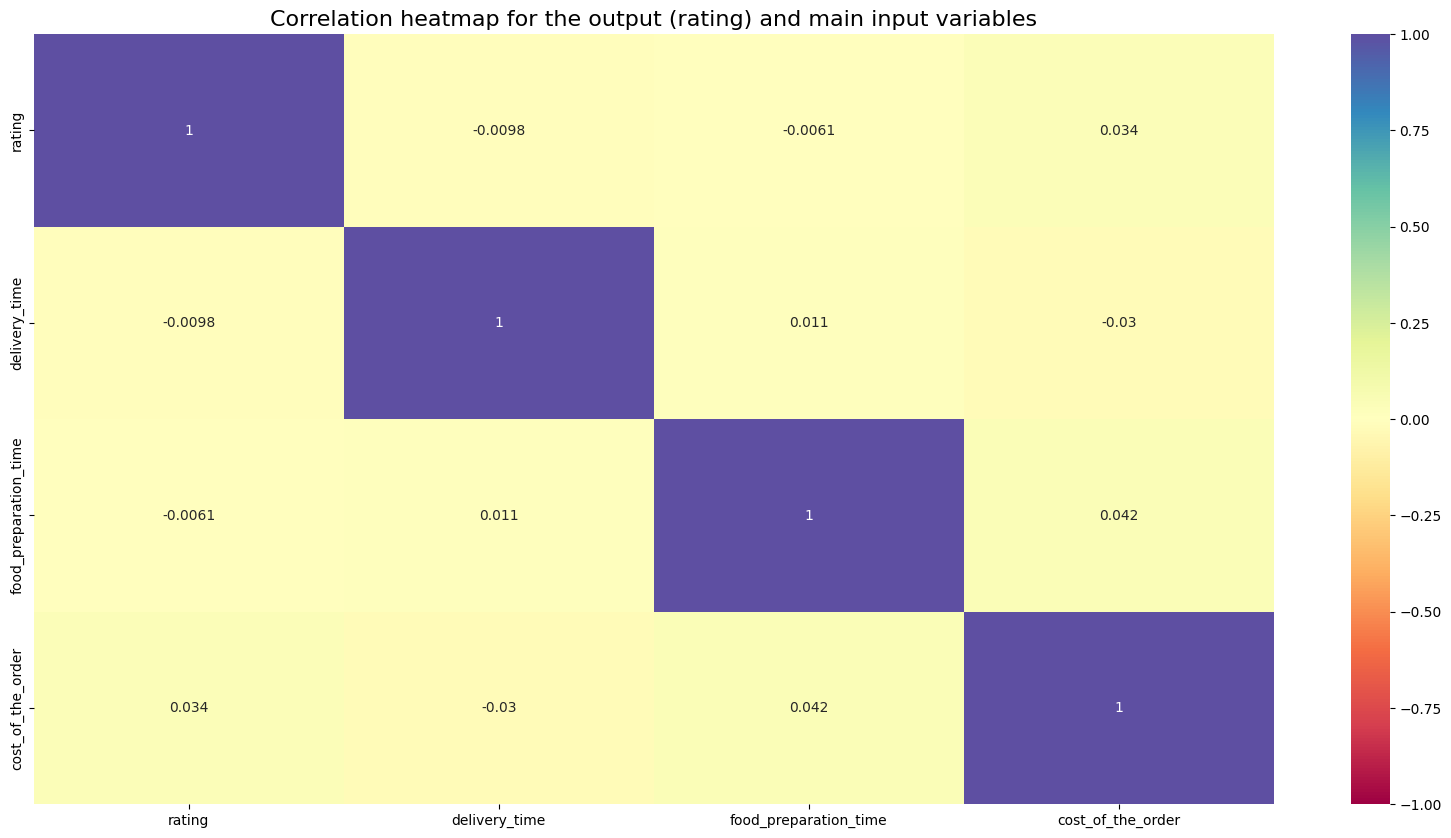

In [ ]:
plt.figure(figsize = (20, 10)) # To resize the plot
df['rating'] = pd.to_numeric(df['rating'], errors = 'coerce')
#df['rating'] = df['rating'].astype(float)

sns.heatmap(df[['rating','delivery_time','food_preparation_time','cost_of_the_order']].corr(), annot = True, cmap = 'Spectral', vmin = -1, vmax = 1)
plt.title("Correlation heatmap for the output (rating) and main input variables", fontsize=16)

plt.show()

**We draw the following conclusions from the above multivariate analysis:**
- we didn't find a relationship between 'rating', 'delivery time', 'food_preparation_time', and 'cost of the order', even when we discriminated according to 'day of the week' or 'cuisine type', and even when we used a single 'cuisine type', or a fixed 'restaurant name'.
- From the rating figures it follows that the rating depends on cuisine type, but it depends in neither delivery time nor weekday.

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer

In [ ]:
 #Fisrst we perform the aggregation that gives each unique restaurante name, with its corresponding rating cont and avg rating
 #We use the Newdf dataframe because it has eliminated the rows containing 'Not given' values in the 'rating'
 df_aggreg_restnames = (
     Newdf.groupby('restaurant_name').agg(
   countval = ('rating', 'count'),
   meanval = ('rating', 'mean'))
     .reset_index()
)

print('The generated aggregated dataframe (last 5 restaurants) consisting of restaurant name and its count and average of rating is: \n')
print(df_aggreg_restnames.tail())

print('\n Now, the info of this dataframe is the following: \n')
df_aggreg_restnames.info()

The generated aggregated dataframe (last 5 restaurants) consisting of restaurant name and its count and average of rating is: 

      restaurant_name  countval   meanval
151    Zero Otto Nove         1  4.000000
152              brgr         1  3.000000
153        da Umberto         1  5.000000
154  ilili Restaurant        13  4.153846
155         indikitch         2  4.500000

 Now, the info of this dataframe is the following: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   restaurant_name  156 non-null    object 
 1   countval         156 non-null    int64  
 2   meanval          156 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 3.8+ KB


In [ ]:
#Now, we apply the conditions, and determine the number of restaurants that satisfy the conditions:
Conditioned_agg_dfrestnames = df_aggreg_restnames.loc[(df_aggreg_restnames['countval']>50) & (df_aggreg_restnames['meanval']>4)]

print('The restaurants satisfying the specified conditions are: \n')

print(Conditioned_agg_dfrestnames)

print('\n The number of restaurantes satisfying the specified conditions is:', len(Conditioned_agg_dfrestnames))

The restaurants satisfying the specified conditions are: 

               restaurant_name  countval   meanval
16   Blue Ribbon Fried Chicken        64  4.328125
17           Blue Ribbon Sushi        73  4.219178
117                Shake Shack       133  4.278195
132          The Meatball Shop        84  4.511905

 The number of restaurantes satisfying the specified conditions is: 4


Observations:
The final answer is: the four restaurants (Shake Shack, The Meatball Shop, Blue Ribbon Sushi, Blue Ribbon Fried Chicken) fulfill the condition: ''the restaurants must have a rating count of more than 50 and the average rating should be greater than 4''


### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders

In [ ]:
def funrechargedcost(s):

    if s > 20:
       return s + s*0.25 # increase of 25%
    elif s > 5:
         return s + s*0.15 # increase of 15%
    else:
         return s # increase of 0%

def funrechargement(s):

    if s > 20:
       return s*0.25 # increase of 25%
    elif s > 5:
         return s*0.15 # increase of 15%
    else:
         return 0 # increase of 0%

Now, we make a new column called 'recharged_cost' that contains the recharged cost, and a new column revenue that contains the revenue.

In [ ]:
df['recharged_cost'] =df['cost_of_the_order'].apply(funrechargedcost)
df['revenue'] =df['cost_of_the_order'].apply(funrechargement)

df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,recharged_cost,revenue
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20,38.4375,7.6875
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23,13.8920,1.8120
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28,14.0645,1.8345
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15,36.5000,7.3000
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24,13.3285,1.7385


Now, we sum the revenue column values, obtaining:

In [ ]:
print('The revenue is:', round(df['revenue'].sum(),3))

The revenue is: 6166.303


### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered)

- The time to get delivered from the time the order is placed is equal to the sum of food_preparation_time and 'delivery_time
- We will sum preparation time and delivering time, and arrange this sum in a new column called 'sum_prep_n_deliv'

In [ ]:
#The time to get delivered from the time the order is placed is equal to the sum of food_preparation_time and 'delivery_time
df['sum_prep_n_deliv'] = df['food_preparation_time'] + df['delivery_time']#df['sum'] = df['column1'] + df['column2']
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,recharged_cost,revenue,sum_prep_n_deliv
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20,38.4375,7.6875,45
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23,13.8920,1.8120,48
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28,14.0645,1.8345,51
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15,36.5000,7.3000,40
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24,13.3285,1.7385,49


In [ ]:
#Now, we find the orders whose 'sum_prep_n_deliv' is greater than 60 min
df_timehigher60 = df.loc[df['sum_prep_n_deliv'] > 60]

#Now, we compute the percentage of orders that satisty this condition:
Percentage_timehigher60 = round(100*len(df_timehigher60)/len(df),2)
print('The percentage or orders exhibiting time higher than 60 is: \n', Percentage_timehigher60, 'percent' )

The percentage or orders exhibiting time higher than 60 is: 
 10.54 percent


### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends?

In [ ]:
# The meand delivery times for weekdays and weekends are:
print('The meand delivery times for weekdays and weekends are: \n')
df.groupby(['day_of_the_week'])['delivery_time'].mean()

The meand delivery times for weekdays and weekends are: 



,delivery_time
day_of_the_week,
Weekday,28.340037
Weekend,22.470022


### **Conclusion and Recommendations**

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations)

### Conclusions:
From a business perspective, it is important to understand the demand of restaurants by customers,
in order to improve the customer experience. Thus, we determined the factors
that affect rating and delivery time, and the nature of their effect.

From the count plots it follows that:
* The count of orders (popularity) is highly dependent on the 'cuisine type',
 'restaurant name', cost range, delivery time, and day of the week,
* The five most popular (higher count) cuisine types on weekends are: American, Japanese, Italian, Chinese and Mexican (from the most preferred to the least preferred)
* The five most popular (higher count) restaurants are: Shake Shack, The Meatball Shop, Blue Ribbon Sushi, Blue Ribbon Fried Chicken, and Parm (from the most preferred to the least preferred)
* The demand (count of orders) is higher on weekends than on weekdays
* In addition, the count of orders is increasing with the rating. This implies that
 the food quality has a strong influence on the demand.  
* The count of orders exhibits a significant decrease for delivery time higher than 30.  

From the plots for rating, delivery time and cost it follows that:
* The dependence of rating on cuisine type is strong, but its dependence with respect to day of week, delivery time,  
 food preparation time, and cost range is low. This implies that the criterion for registration of rating is straightforwardly related to
 food quality, and not on other variables.
* The delivery time depends on the day of the week
* The dependence of delivery time on cuisine type and restaurant name is weak
* The cost of the order depends on the cuisine type, but it does not depend on day of the week (in average)
* The dependence of food preparation time with cuisine type is not strong

Other conclusions:
* 29.2 % of orders cost more than 20 dollars.
* The mean delivery time is 24.2 min
* 10.5 % of the orders have a time (time to get delivered from the time the order is placed) higher than 60 minutes.

### Recommendations:
* Since the count of orders exhibits a significant decrease for delivery time higher than 28 during weekdays, it is recommended to identify the corresponding restaurants or circumstances, and solve this issue. These higher delivery times occur during weekdays.

* It is recommended to perform marketing campaign for the restaurants with higher demand. Also, it would be convenient to identify the three restaurants with higher demand (and higher rating) for each cuisine type, and make publicity for these. This would facilitate the people to choose apropriate foods, in special to those who haven't a certain decision.     

* It is recommended to use a more detailed rating, using numbers 3.0, 3.2, 3.4, .....4.6, 4.8, 5.0, instead of the current numbers used (3.0, 4.0, 5.0). This would lead to a  better understanding of the dependence of 'rating' with respect to the different input variables.

* It is recommended to use a more detailed racording of the 'day of week', specifying the exact day of the week, not the current binary category (weekend/weekday). This would allow to understand the dependence of rating and count with respect to day of the week, and also it would allow to identify the days with higher delivery time and to solve it.

* After improving the recording of 'rating' and 'day_of_the_week' values, the EDA can be made again, leading to deeper conclusions and recommendations.